In [38]:
import numpy as np
import pandas as pd

import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
def _classificar_perfil_regra(renda, gastos, endividamento, poupanca_mensal,
                                reserva_financeira, meses_saldo_negativo):
    margem = renda - gastos
    comprometimento = (gastos / renda * 100) if renda > 0 else 100
    taxa_poupanca = (poupanca_mensal / renda * 100) if renda > 0 else 0
    meses_reserva = reserva_financeira / gastos if gastos > 0 else 0

    if margem < 0 or endividamento >= 50 or meses_saldo_negativo >= 2:
        return "em_risco"

    if comprometimento <= 70 and endividamento <= 20 and taxa_poupanca >= 15 and meses_reserva >= 3:
        return "saudavel"

    return "em_observacao"


def _separar_poupanca_e_reserva(renda_mensal, total_gastos, rng, forcar_saudavel=False):
    margem = max(renda_mensal - total_gastos, 0)
    if forcar_saudavel and margem > 0:
        poupanca_mensal = round(margem * rng.uniform(0.45, 0.7), 2)
        reserva_financeira = round(renda_mensal * rng.uniform(2.0, 5.0), 2)
    else:
        poupanca_mensal = round(margem * rng.uniform(0, 0.6), 2) if margem > 0 else 0.0
        reserva_financeira = round(renda_mensal * rng.uniform(0, 4), 2)
    return poupanca_mensal, reserva_financeira


def gerar_dataset_perfil_simulado(n_amostras: int = 1200, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    registros = []

    for i in range(n_amostras):
        forcar_saudavel = i % 3 == 0  # ~33% das iterações tendendo a saudável

        renda_mensal = round(float(rng.uniform(1200, 15000)), 2)

        if forcar_saudavel:
            percentual_gasto = rng.uniform(0.3, 0.55)
            endividamento = round(float(rng.uniform(0, 20)), 2)
        else:
            percentual_gasto = rng.uniform(0.3, 1.3)
            endividamento = round(float(rng.uniform(0, 90)), 2)

        total_gastos = round(renda_mensal * percentual_gasto, 2)

        poupanca_mensal, reserva_financeira = _separar_poupanca_e_reserva(
            renda_mensal, total_gastos, rng, forcar_saudavel=forcar_saudavel
        )

        if forcar_saudavel:
            meses_saldo_negativo = int(rng.integers(0, 1))  # 0
        else:
            meses_saldo_negativo = int(rng.integers(0, 6)) if percentual_gasto > 1 else int(rng.integers(0, 2))

        percentual_essenciais = round(float(rng.uniform(40, 90)), 2)
        ticket_medio = round(float(rng.uniform(30, 500)), 2)
        percentual_recorrentes = round(float(rng.uniform(10, 70)), 2)

        perfil = _classificar_perfil_regra(
            renda_mensal, total_gastos, endividamento,
            poupanca_mensal, reserva_financeira, meses_saldo_negativo
        )

        registros.append({
            "renda_mensal_liquida": renda_mensal,
            "despesa_total": total_gastos,
            "nivel_endividamento": endividamento,
            "poupanca_mensal": poupanca_mensal,
            "reserva_financeira": reserva_financeira,
            "meses_saldo_negativo": meses_saldo_negativo,
            "percentual_essenciais": percentual_essenciais,
            "ticket_medio": ticket_medio,
            "percentual_recorrentes": percentual_recorrentes,
            "margem_sobra": round(renda_mensal - total_gastos, 2),
            "comprometimento_renda": round((total_gastos / renda_mensal) * 100, 2),
            "taxa_poupanca": round((poupanca_mensal / renda_mensal) * 100, 2),
            "meses_reserva": round(reserva_financeira / total_gastos, 2) if total_gastos > 0 else 0.0,
            "perfil": perfil,
        })

    return pd.DataFrame(registros)


In [53]:
df_perfil = gerar_dataset_perfil_simulado(n_amostras=1200)

df_perfil.head()

,renda_mensal_liquida,despesa_total,nivel_endividamento,poupanca_mensal,reserva_financeira,meses_saldo_negativo,percentual_essenciais,ticket_medio,percentual_recorrentes,margem_sobra,comprometimento_renda,taxa_poupanca,meses_reserva,perfil
0,11880.59,4867.71,17.17,4378.44,27117.83,0,88.78,387.74,57.16,7012.88,40.97,36.85,5.57,saudavel
1,2967.97,2227.12,33.37,411.96,7643.89,0,62.17,136.80,43.28,740.85,75.04,13.88,3.43,em_observacao
2,2080.68,2346.24,56.85,0.00,6309.35,4,57.73,486.23,63.59,-265.56,112.76,0.00,2.69,em_risco
3,11941.69,4163.59,9.33,3585.32,29410.81,0,74.15,380.04,68.05,7778.10,34.87,30.02,7.06,saudavel
4,5696.39,3819.20,42.26,213.40,2960.33,1,51.35,344.81,36.23,1877.19,67.05,3.75,0.78,em_observacao


**EDA rápida**

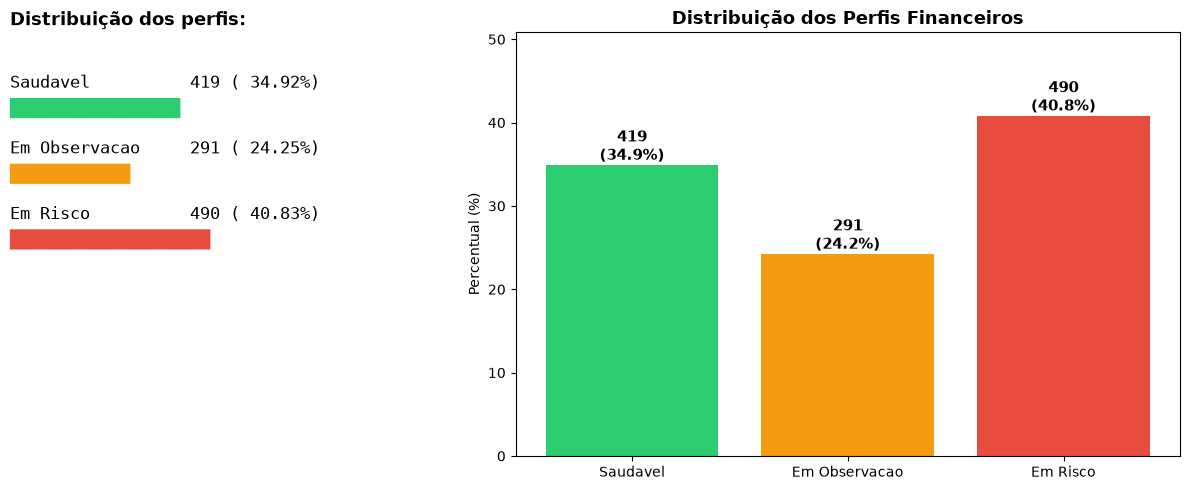

In [54]:
ordem = ["saudavel", "em_observacao", "em_risco"]
cores = {"saudavel": "#2ecc71", "em_observacao": "#f39c12", "em_risco": "#e74c3c"}

quantidade = df_perfil["perfil"].value_counts().reindex(ordem)

distribuicao = (
    df_perfil["perfil"]
    .value_counts(normalize=True)
    .reindex(ordem)
    .mul(100)
    .round(2)
)

fig, (ax_texto, ax_grafico) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.5]})

ax_texto.axis("off")
ax_texto.text(0, 1.05, "Distribuição dos perfis:", fontsize=13, fontweight="bold", va="top", ha="left")

y_pos = 0.9
for perfil in ordem:
    pct = distribuicao[perfil]
    qtd = quantidade[perfil]
    barra = "█" * int(pct / 2)
    nome = perfil.replace("_", " ").title()

    ax_texto.text(0, y_pos, f"{nome:<15} {qtd:>5} ({pct:>6.2f}%)",
                  fontsize=12, family="monospace", va="top", ha="left", color="black")
    y_pos -= 0.055

    ax_texto.text(0, y_pos, barra, fontsize=12, family="monospace",
                  va="top", ha="left", color=cores[perfil])
    y_pos -= 0.10

barras = ax_grafico.bar(
    [p.replace("_", " ").title() for p in ordem],
    distribuicao.values,
    color=[cores[p] for p in ordem]
)

for bar, perfil, pct in zip(barras, ordem, distribuicao.values):
    qtd = quantidade[perfil]
    ax_grafico.annotate(
        f"{qtd}\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax_grafico.set_title("Distribuição dos Perfis Financeiros", fontsize=13, fontweight="bold")
ax_grafico.set_ylabel("Percentual (%)")
ax_grafico.set_ylim(0, max(distribuicao.values) + 10)

plt.tight_layout()
plt.show()


**Engenharia de atributos (seleção das features)**

In [55]:
features = [
    "renda_mensal_liquida", "despesa_total", "nivel_endividamento",
    "poupanca_mensal", "reserva_financeira", "meses_saldo_negativo",
    "percentual_essenciais", "ticket_medio", "percentual_recorrentes",
    "margem_sobra", "comprometimento_renda", "taxa_poupanca", "meses_reserva"
]

X = df_perfil[features]
y = df_perfil["perfil"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'em_observacao': 0, 'em_risco': 1, 'saudavel': 2}


**Split treino/teste + normalização**

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Tuning de hiperparâmetros — GradientBoostingClassifier**

In [57]:
param_grid = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [None, 5, 10],
    "l2_regularization": [0, 0.1, 1],
}

random_search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42, early_stopping=True),
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1_macro",
    cv=2,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", random_search.best_params_)
print("Melhor F1-macro (CV):", random_search.best_score_)


Fitting 2 folds for each of 15 candidates, totalling 30 fits
Melhores parâmetros: {'max_iter': 200, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 0}
Melhor F1-macro (CV): 0.9896311061478354


**Validação no conjunto de teste**

In [58]:
y_pred = random_search.best_estimator_.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print("F1-macro (teste):", f1_score(y_test, y_pred, average="macro"))


               precision    recall  f1-score   support

em_observacao       0.98      1.00      0.99        58
     em_risco       1.00      1.00      1.00        98
     saudavel       1.00      0.99      0.99        84

     accuracy                           1.00       240
    macro avg       0.99      1.00      1.00       240
 weighted avg       1.00      1.00      1.00       240

F1-macro (teste): 0.9951549891669652


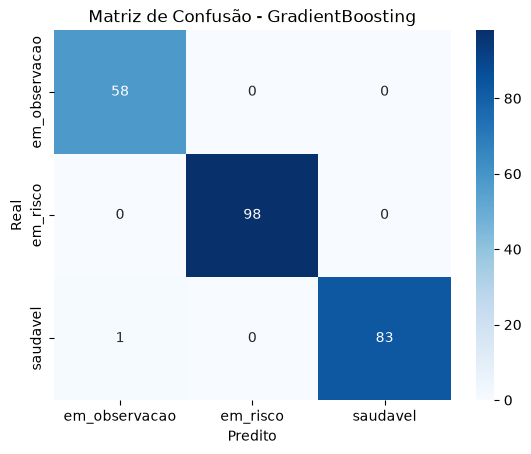

In [59]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - GradientBoosting")
plt.show()


**Validação cruzada extra (robustez)**

In [60]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo = random_search.best_estimator_
scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring="f1_macro")
print(f"F1-macro médio (CV): {scores.mean():.4f} ± {scores.std():.4f}")


F1-macro médio (CV): 0.9940 ± 0.0053


**Importância das variáveis**

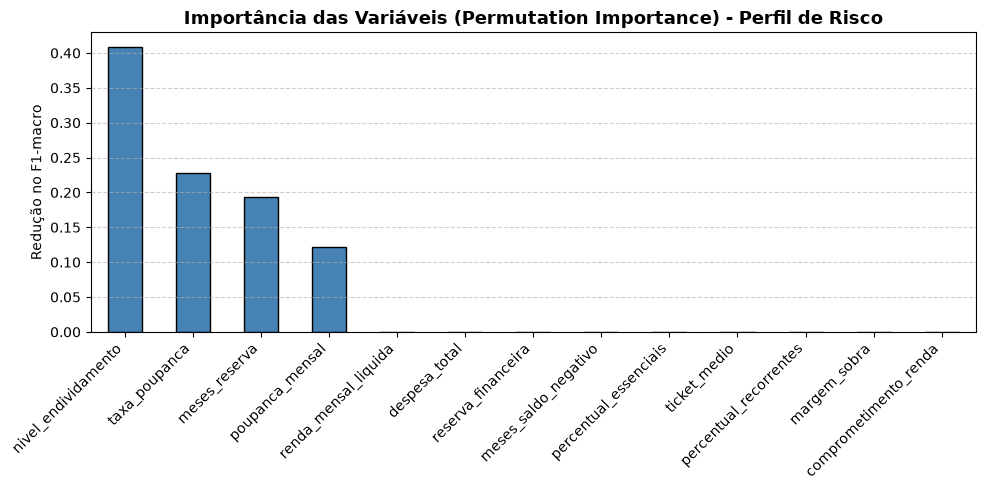

In [61]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    modelo, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring="f1_macro", n_jobs=-1
)

importancias = pd.Series(result.importances_mean, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Importância das Variáveis (Permutation Importance) - Perfil de Risco", fontsize=13, fontweight="bold")
plt.ylabel("Redução no F1-macro")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Exportar**

In [63]:
os.makedirs("../models", exist_ok=True)

joblib.dump(modelo, "../models/gb_profile.pkl")
joblib.dump(scaler, "../models/scaler_profile.pkl")
joblib.dump(le, "../models/label_encoder_profile.pkl")

print("✅ gb_profile.pkl salvo em ../models/")


✅ gb_profile.pkl salvo em ../models/


**Sanity check (confirma que salvou certo)**

In [64]:
modelo_teste = joblib.load("../models/gb_profile.pkl")
scaler_teste = joblib.load("../models/scaler_profile.pkl")
le_teste = joblib.load("../models/label_encoder_profile.pkl")

amostra = X_test.iloc[[0]]
pred = modelo_teste.predict(scaler_teste.transform(amostra))
print("Predito:", le_teste.inverse_transform(pred)[0])
print("Real:", le.inverse_transform([y_test[0]])[0])


Predito: em_risco
Real: em_risco
